# 01 — EDA: Give Me Some Credit

**Dataset provenance (honesty statement).** Kaggle "Give Me Some Credit"
(2011), 150,000 labeled rows, target = serious delinquency / financial
distress within two years. The originating institution, geography, and
sampling frame are **not established** in public documentation. Nothing here
is Capital One data, and results are a methodological prototype — see
`DESIGN_FREEZE.md` §1.

**Holdout discipline.** All **target-aware** statistics in this notebook
(default rates, risk-by-segment tables) are computed on **RISK-DEV only**
(the 80% development split), via dev-restricted SQL views. Feature-only
statistics (distributions, missingness, sentinel co-occurrence) use the full
file — features are observable at scoring time; only labels carry holdout
information. An earlier version of this notebook computed target-aware EDA
on the full population, which contaminated the "untouched holdout" claim;
that is disclosed in the `DESIGN_FREEZE.md` amendment log, RISK-TEST is now
framed as a **fixed secondary holdout diagnostic**, and the primary
generalization evidence is nested outer CV on RISK-DEV.

This notebook reads from the SQLite warehouse built by `src/load_db.py`
(raw table + cleaning views + dev-only segment views in `sql/`).

In [1]:
import sqlite3
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))
from src import config, data_prep  # noqa: E402

con = sqlite3.connect(config.DB_PATH)
raw = pd.read_sql("SELECT * FROM raw_credit", con)          # feature-only uses
dev = pd.read_sql(
    "SELECT r.* FROM raw_credit r JOIN risk_dev_ids USING (customer_id)", con
)                                                            # target-aware uses
print(f"full file: {raw.shape}   RISK-DEV: {dev.shape}")
dev.head()

full file: (150000, 12)   RISK-DEV: (120000, 12)


,customer_id,serious_dlqin2yrs,revolving_utilization,age,dpd_30_59,debt_ratio,monthly_income,open_credit_lines,dpd_90,real_estate_loans,dpd_60_89,dependents
0,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
1,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
2,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
3,6,0,0.213179,74,0,0.375607,3500.0,3,0,1,0,1.0
4,7,0,0.305682,57,0,5710.000000,NaN,8,0,3,0,0.0


## Class imbalance and missingness

In [2]:
target_rate = dev["serious_dlqin2yrs"].mean()
print(f"RISK-DEV default rate: {target_rate:.4%}  ->  PR-AUC baseline (random) = {target_rate:.4f}")
missing = raw.drop(columns=["serious_dlqin2yrs"]).isna().mean().sort_values(ascending=False)
missing[missing > 0].to_frame("missing_fraction (full file, feature-only)")

RISK-DEV default rate: 6.6842%  ->  PR-AUC baseline (random) = 0.0668


,"missing_fraction (full file, feature-only)"
monthly_income,0.198207
dependents,0.026160


~6.7% positives — imbalanced enough that ROC-AUC alone can flatter a model;
we therefore also report PR-AUC and KS in Layer 1. Missingness is
concentrated in `monthly_income` (~20%) and `dependents` (~2.6%); both get
missing-indicator flags and (for the scorecard) their own WOE bin, never a
silent imputation.

## Quirk 1 — sentinel codes 96/98 in the delinquency-count fields

The evidence that these are special codes rather than genuine counts:
they co-occur in the **same rows across all three fields** (a feature-only
fact, shown on the full file). Their default rate is computed on RISK-DEV.

In [3]:
pd.read_sql("""
SELECT dpd_30_59 IN (96,98) AS s3059, dpd_60_89 IN (96,98) AS s6089,
       dpd_90 IN (96,98) AS s90, COUNT(*) AS n_full_file
FROM raw_credit
WHERE dpd_30_59 IN (96,98) OR dpd_60_89 IN (96,98) OR dpd_90 IN (96,98)
GROUP BY s3059, s6089, s90
""", con)

,s3059,s6089,s90,n_full_file
0,1,1,1,269


In [4]:
pd.read_sql("""
SELECT COUNT(*) AS n_dev, AVG(serious_dlqin2yrs) AS default_rate_dev
FROM raw_credit r JOIN risk_dev_ids USING (customer_id)
WHERE dpd_30_59 IN (96,98) OR dpd_60_89 IN (96,98) OR dpd_90 IN (96,98)
""", con)

,n_dev,default_rate_dev
0,229,0.545852


All 269 flagged rows carry the code in *all three* fields simultaneously —
a count interpretation would mean someone was 30-59, 60-89, **and** 90+ days
late 96+ times each, which is not a credible payment history. Their RISK-DEV
default rate (~55%) is 8x the population rate, so the rows are informative
and must not be dropped.

**Frozen primary rule (`DESIGN_FREEZE.md` §4.1):** `dpd_sentinel_flag` = 1,
counts set to missing; the flag carries the risk signal. Sensitivity
analyses re-run the models with (a) counts capped at the max non-sentinel
value and (b) rows dropped — results in notebook 02.

## Quirk 2 — revolving utilization > 1

In [5]:
util_dev = dev["revolving_utilization"]
summary = pd.DataFrame({
    "n_dev": [len(util_dev), (util_dev > 1).sum(), (util_dev > 2).sum(), (util_dev > 10).sum()],
    "default_rate_dev": [
        dev["serious_dlqin2yrs"].mean(),
        dev.loc[util_dev > 1, "serious_dlqin2yrs"].mean(),
        dev.loc[util_dev > 2, "serious_dlqin2yrs"].mean(),
        dev.loc[util_dev > 10, "serious_dlqin2yrs"].mean(),
    ],
}, index=["all", "util > 1", "util > 2", "util > 10"])
summary

,n_dev,default_rate_dev
all,120000,0.066842
util > 1,2666,0.374344
util > 2,297,0.151515
util > 10,184,0.076087


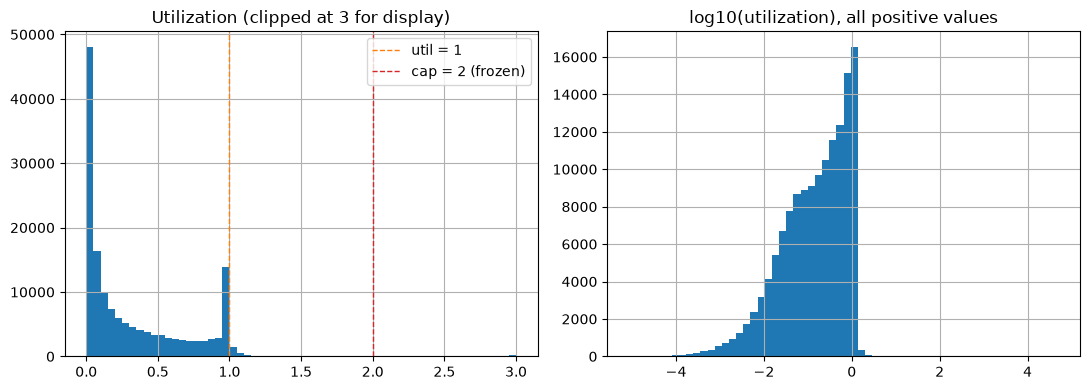

In [6]:
util = raw["revolving_utilization"]  # distribution shape: feature-only, full file
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
util.clip(upper=3).hist(bins=60, ax=axes[0])
axes[0].axvline(1.0, color="tab:orange", ls="--", lw=1, label="util = 1")
axes[0].axvline(2.0, color="tab:red", ls="--", lw=1, label="cap = 2 (frozen)")
axes[0].set_title("Utilization (clipped at 3 for display)")
axes[0].legend()
np.log10(util[util > 0]).hist(bins=60, ax=axes[1])
axes[1].set_title("log10(utilization), all positive values")
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "eda_utilization.png", dpi=150, bbox_inches="tight")

Values in (1, 2] are plausible over-limit utilization. Beyond 2 the tail
stretches into the tens of thousands; whatever the mechanism (we do **not**
assert one), the exact magnitudes are not trustworthy as ratios.

**Frozen primary rule (§4.2): cap at 2.0 + `util_extreme_flag`**, with the
monotone constraint applied to the capped variable. Sensitivity analyses:
(a) values > 2 set to missing, (b) p99 winsorization.

## Quirk 3 (minor) — DebtRatio changes meaning when income is missing

In [7]:
pd.read_sql("""
SELECT income_missing_flag,
       COUNT(*) AS n,
       AVG(debt_ratio) AS mean_debt_ratio,
       AVG(serious_dlqin2yrs) AS default_rate
FROM v_clean_dev GROUP BY income_missing_flag
""", con)

,income_missing_flag,n,mean_debt_ratio,default_rate
0,0,96140,27.550955,0.069222
1,1,23860,1675.849329,0.057251


With income missing, `debt_ratio` averages in the hundreds — it is not the
same quantity (a ratio needs a denominator). `income_missing_flag` therefore
doubles as a DebtRatio validity flag for the models.

## Target rate by segment (dev-only SQL views)

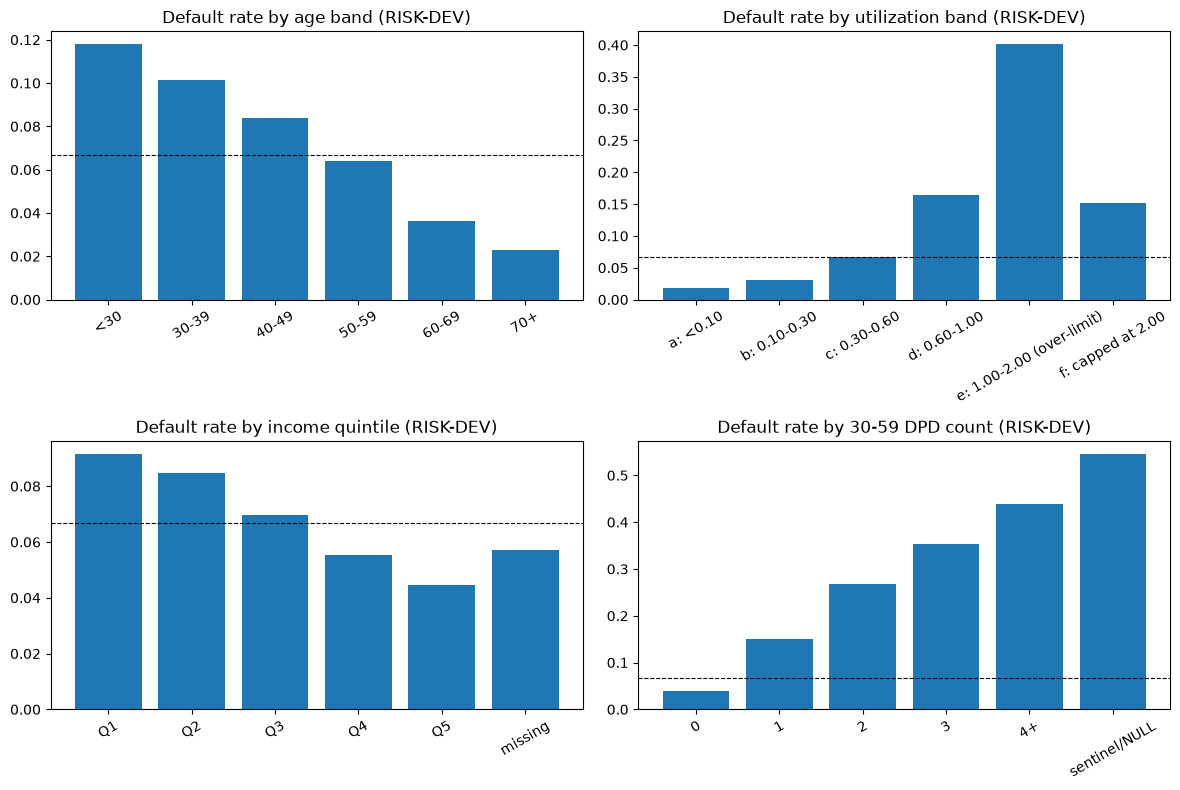

In [8]:
seg_age = pd.read_sql("SELECT * FROM v_default_by_age", con)
seg_util = pd.read_sql("SELECT * FROM v_default_by_util", con)
seg_inc = pd.read_sql("SELECT * FROM v_default_by_income", con)
seg_dpd = pd.read_sql("SELECT * FROM v_default_by_dpd3059", con)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, (seg, col, title) in zip(axes.ravel(), [
    (seg_age, "age_band", "Default rate by age band (RISK-DEV)"),
    (seg_util, "util_band", "Default rate by utilization band (RISK-DEV)"),
    (seg_inc, "income_segment", "Default rate by income quintile (RISK-DEV)"),
    (seg_dpd, "dpd_30_59_band", "Default rate by 30-59 DPD count (RISK-DEV)"),
]):
    ax.bar(seg[col], seg["default_rate"])
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30)
    ax.axhline(target_rate, color="k", ls="--", lw=0.8)
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "eda_segments.png", dpi=150, bbox_inches="tight")

Patterns are exactly what domain knowledge predicts — risk falls with age
and income, rises steeply with utilization and delinquency count. The
monotone directions frozen for the LightGBM constraints (utilization,
delinquency counts) are visible here in the **development data**; we
deliberately do not constrain age or income (§5).

One row has `age = 0` — treated as missing (§4.3). The data documents no
lower age limit, so the youngest segment is labeled "<30".

## Feature distributions (full file, feature-only)

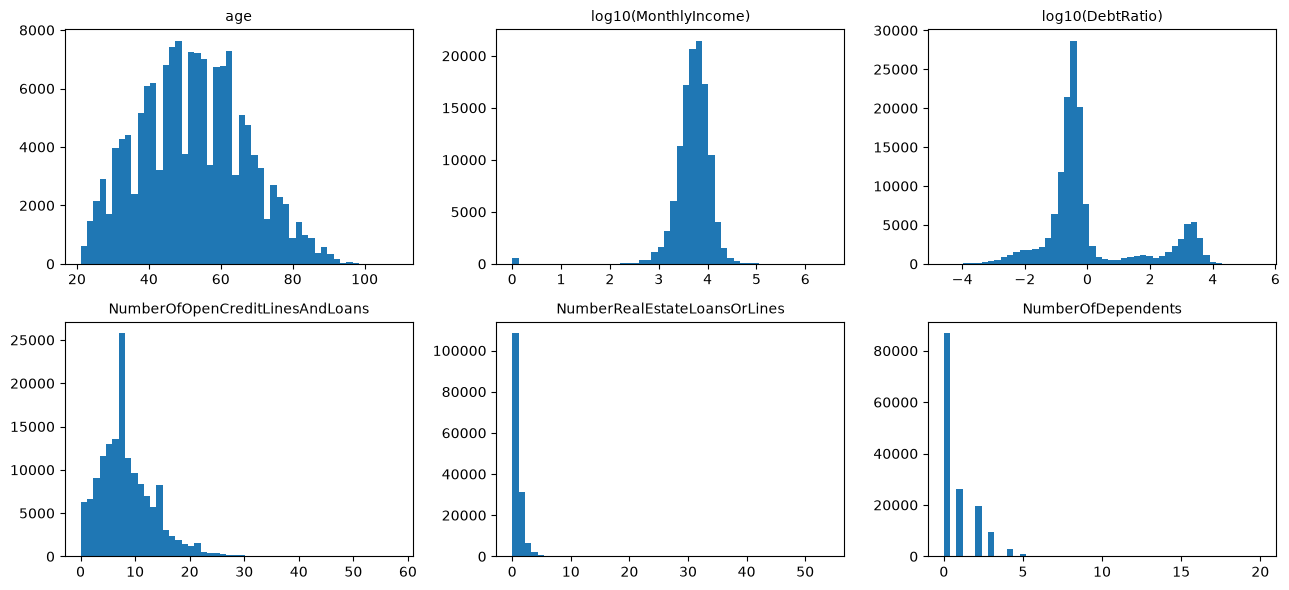

In [9]:
clean = data_prep.CleaningRules("primary").fit_transform(data_prep.load_raw())
num_cols = ["age", "MonthlyIncome", "DebtRatio", "NumberOfOpenCreditLinesAndLoans",
            "NumberRealEstateLoansOrLines", "NumberOfDependents"]
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, c in zip(axes.ravel(), num_cols):
    x = clean[c].dropna()
    if c in ("MonthlyIncome", "DebtRatio"):
        x = np.log10(x[x > 0])
        c = f"log10({c})"
    ax.hist(x, bins=50)
    ax.set_title(c, fontsize=10)
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "eda_distributions.png", dpi=150, bbox_inches="tight")

In [10]:
con.close()

## Frozen handling summary (feeds Layer 1)

| Quirk | Primary rule (frozen) | Sensitivity analyses |
|---|---|---|
| 96/98 sentinels (3 DPD fields, 269 rows) | flag + counts → missing | cap at max non-sentinel; drop rows |
| utilization > 1 | cap at 2.0 + flag; (1,2] kept | >2 → missing; p99 winsorize |
| income missing (~20%) | flag + own WOE bin / native NaN | — |
| DebtRatio w/ missing income | validity flag (= income flag) | — |
| age = 0 (1 row) | → missing | — |